In [2]:
# Import libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
# load training set
data_train = pd.read_csv('mnist_train_small.csv', header=None)
data_train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data_train.shape

(20000, 785)

In [5]:
# Separate X and y and normalize X
data_train_arr = data_train.to_numpy()
X = data_train_arr[:, 1:]
y = data_train_arr[:, 0]

print(X.shape)
print(y.shape)

(20000, 784)
(20000,)


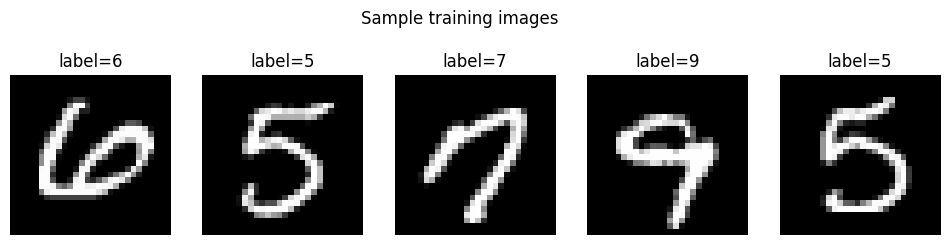

In [6]:
import matplotlib.pyplot as plt

sample_idxs = np.arange(5)
sample_images = X[sample_idxs]
sample_labels = y[sample_idxs]

fig, axes = plt.subplots(1, len(sample_idxs), figsize=(12, 3))
for ax, img, label in zip(axes, sample_images, sample_labels):
    ax.imshow(img.reshape(28, 28), cmap='gray')
    ax.set_title(f'label={label}')
    ax.axis('off')

plt.suptitle('Sample training images')
plt.show()

In [7]:
# Separate X and y and normalize X
data_train_arr = data_train.to_numpy()
X = X / 255
y = data_train_arr[:, 0]

print(X.shape)
print(y.shape)

(20000, 784)
(20000,)


In [8]:
y

array([6, 5, 7, ..., 2, 9, 5], shape=(20000,))

In [9]:
# Convert array to tensor
tX = torch.tensor(X, dtype=torch.float32)
ty = torch.tensor(y, dtype=torch.long)

In [10]:
# Build ANN Model
def model(X, W1, b1, W2, b2, W3, b3):
  # layer 1
  Z1 = torch.matmul(X, W1) + b1
  A1 = torch.sigmoid(Z1)

  # layer 2
  Z2 = torch.matmul(A1, W2) + b2
  A2 = torch.sigmoid(Z2)

  # layer 3
  Z3 = torch.matmul(A2, W3) + b3

  return Z3

In [14]:
# Training
# Initial weights
W1 = torch.randn((784, 64), dtype=torch.float32, requires_grad=True)
b1 = torch.randn((1, 64), dtype=torch.float32, requires_grad=True)
W2 = torch.randn((64, 32), dtype=torch.float32, requires_grad=True)
b2 = torch.randn((1, 32), dtype=torch.float32, requires_grad=True)
W3 = torch.randn((32, 10), dtype=torch.float32, requires_grad=True)
b3 = torch.randn((1, 10), dtype=torch.float32, requires_grad=True)

# Optimizer
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr=0.1)

# Cost function
cost_fn = nn.CrossEntropyLoss()

# Training loop
for epoch in range(500):
  bath_size = 100
  for i in range(0, len(tX), bath_size):
    X_batch = tX[i:i+bath_size]
    y_batch = ty[i:i+bath_size]
    y_pred = model(X_batch, W1, b1, W2, b2, W3, b3)
    loss = cost_fn(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f'Epoch: {epoch+1:03d}, Bath number: {i/bath_size},  Loss: {loss.item():.4f}')

Epoch: 001, Bath number: 0.0,  Loss: 4.9794
Epoch: 001, Bath number: 1.0,  Loss: 4.5885
Epoch: 001, Bath number: 2.0,  Loss: 4.7910
Epoch: 001, Bath number: 3.0,  Loss: 4.1834
Epoch: 001, Bath number: 4.0,  Loss: 4.5788
Epoch: 001, Bath number: 5.0,  Loss: 3.8665
Epoch: 001, Bath number: 6.0,  Loss: 3.9478
Epoch: 001, Bath number: 7.0,  Loss: 4.1186
Epoch: 001, Bath number: 8.0,  Loss: 3.5275
Epoch: 001, Bath number: 9.0,  Loss: 3.6580
Epoch: 001, Bath number: 10.0,  Loss: 3.7235
Epoch: 001, Bath number: 11.0,  Loss: 3.5101
Epoch: 001, Bath number: 12.0,  Loss: 3.4650
Epoch: 001, Bath number: 13.0,  Loss: 3.3944
Epoch: 001, Bath number: 14.0,  Loss: 3.4530
Epoch: 001, Bath number: 15.0,  Loss: 3.6103
Epoch: 001, Bath number: 16.0,  Loss: 3.1407
Epoch: 001, Bath number: 17.0,  Loss: 3.1331
Epoch: 001, Bath number: 18.0,  Loss: 3.2887
Epoch: 001, Bath number: 19.0,  Loss: 3.4118
Epoch: 001, Bath number: 20.0,  Loss: 3.0911
Epoch: 001, Bath number: 21.0,  Loss: 2.9068
Epoch: 001, Bath num

In [16]:
# Prepare test set
data_test = pd.read_csv('mnist_test.csv', header=None)
#data_test.head()

data_test_arr = data_test.to_numpy()
X_test = data_test_arr[:, 1:] / 255
y_test = data_test_arr[:, 0]

print(X_test.shape)
print(y_test.shape)

tX_test = torch.tensor(X_test, dtype=torch.float32)
ty_test = torch.tensor(y_test, dtype=torch.long)

(10000, 784)
(10000,)


In [17]:
# Evaluate the model using test set
with torch.no_grad():
  h = model(tX_test, W1, b1, W2, b2, W3, b3)
  y_pred = torch.argmax(h,dim=1)
  accuracy = (y_pred == ty_test).sum()/len(ty_test)
  print(f'Model accouracy = {accuracy.item()*100:.2f}%')

Model accouracy = 92.02%


In [19]:
# test 0
import cv2 as cv

im_0 = cv.imread('tiny_mnist/0/1.png', cv.IMREAD_GRAYSCALE)
im_0 = cv.resize(im_0, (28, 28))
im_0 = im_0 / 255

t_im_0 = torch.tensor(im_0, dtype=torch.float32)

h_0 = model(t_im_0.reshape(1, -1), W1, b1, W2, b2, W3, b3)
y_pred_0 = torch.argmax(h_0,dim=1)
print(f"Model predicts the image as number {y_pred_0.item()}.")

Model predicts the image as number 0.


In [20]:
# test 1
im_1 = cv.imread('tiny_mnist/1/3.png', cv.IMREAD_GRAYSCALE)
im_1 = cv.resize(im_1, (28, 28))
im_1 = im_1 / 255

t_im_1 = torch.tensor(im_1, dtype=torch.float32)

h_1 = model(t_im_1.reshape(1, -1), W1, b1, W2, b2, W3, b3)
y_pred_1 = torch.argmax(h_1,dim=1)
print(f"Model predicts the image as number {y_pred_1.item()}.")

Model predicts the image as number 1.


In [21]:
# test 2
im_2 = cv.imread('tiny_mnist/2/5.png', cv.IMREAD_GRAYSCALE)
im_2 = cv.resize(im_2, (28, 28))
im_2 = im_2 / 255

t_im_2 = torch.tensor(im_2, dtype=torch.float32)

h_2 = model(t_im_2.reshape(1, -1), W1, b1, W2, b2, W3, b3)
y_pred_2 = torch.argmax(h_2,dim=1)
print(f"Model predicts the image as number {y_pred_2.item()}.")

Model predicts the image as number 2.


In [22]:
# Try KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

# evaluate KNN
knn.score(X_test, y_test)

0.9591

In [23]:
knn.predict(im_2.reshape(1, -1))

array([2])

In [24]:
knn.predict(im_1.reshape(1, -1))

array([1])

In [25]:
knn.predict(im_0.reshape(1, -1))

array([0])